<a href="https://colab.research.google.com/github/giannismantzaris-cmd/DAMA61/blob/main/Mantzaris_WA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#All needed imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(42)
tf.random.set_seed(42)


In [2]:
from tensorflow.keras.datasets import cifar10
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
print(X_train_full.shape)
print(X_test.shape)


(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [4]:
# The dataset is already split it train (50000)and test (10000) set. But I need
# the full dataset (60000) to shuffle it and split it in train, validation and
# tsst set.
X = np.concatenate([X_train_full, X_test], axis=0)
y = np.concatenate([y_train_full, y_test], axis=0)
print(X.shape)

(60000, 32, 32, 3)


In [5]:
#normalize the data by diving with 255
X = X / 255.

In [6]:
# Shuffle
np.random.seed(42)
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

In [7]:
# Split 60/20/20
X_train = X[:36000]
y_train = y[:36000]

X_valid = X[36000:48000]
y_valid = y[36000:48000]

X_test = X[48000:]
y_test = y[48000:]

In [8]:
# Print shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (36000, 32, 32, 3)
y_train: (36000, 1)
X_valid: (12000, 32, 32, 3)
y_valid: (12000, 1)
X_test: (12000, 32, 32, 3)
y_test: (12000, 1)


In [9]:
#create the model
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(20, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [10]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        61,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,780 (241.33 KB)

 Trainable params: 61,780 (241.33 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#training and evaluating the model
history = model.fit(X_train, y_train, epochs=40,batch_size=64,
                    validation_data=(X_valid, y_valid))

Epoch 1/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1707 - loss: 2.2069 - val_accuracy: 0.2438 - val_loss: 2.0293
Epoch 2/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2636 - loss: 1.9820 - val_accuracy: 0.2882 - val_loss: 1.9327
Epoch 3/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2969 - loss: 1.9173 - val_accuracy: 0.3071 - val_loss: 1.8915
Epoch 4/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3168 - loss: 1.8782 - val_accuracy: 0.3287 - val_loss: 1.8564
Epoch 5/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3322 - loss: 1.8476 - val_accuracy: 0.3368 - val_loss: 1.8492
Epoch 6/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3464 - loss: 1.8204 - val_accuracy: 0.3452 - val_loss: 1.8298
Epoch 7/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3550 - loss: 1.7963 - val_accuracy: 0.3518 - val_loss: 1.8114
Epoch 8/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3612 - loss: 1.7755 - val_accuracy: 0.

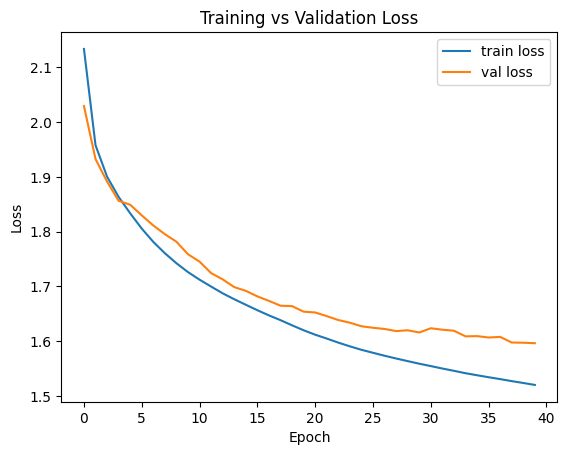

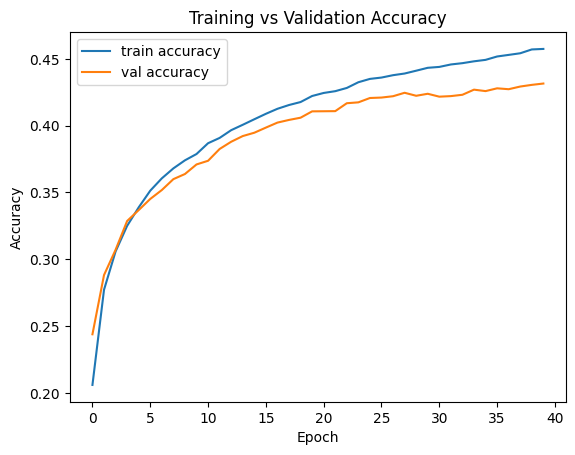

In [13]:
# Loss plot
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Accuracy plot
plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Both training and validation loss decrease steadily while accuracy increases over epochs, indicating stable learning. The small gap between training and validation accuracy, mainly visible in later epochs, is indicating a mild overfitting, but the model still generalizes well. However , the models performance is quite poor, with a validation set accuracy about 43%

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4322 - loss: 1.5787
Test loss: 1.5906355381011963
Test accuracy: 0.429833322763443


The test accuracy is very close to the validation accuracy, indicating that the model generalizes similarly to unseen data. The overall accuracy remains low, confirming that the baseline MLP fails to classify correctly the CIFAR-10 dataset.

In [15]:
model_2 = tf.keras.Sequential()
model_2.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model_2.add(tf.keras.layers.Flatten())
model_2.add(tf.keras.layers.Dense(100, activation="relu"))
model_2.add(tf.keras.layers.Dense(50, activation="relu"))
model_2.add(tf.keras.layers.Dense(10, activation="softmax"))

model_2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [16]:
#training and evaluating the new model
history_2 = model_2.fit(X_train, y_train, epochs=40,batch_size=64,
                    validation_data=(X_valid, y_valid))

Epoch 1/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2282 - loss: 2.1147 - val_accuracy: 0.3298 - val_loss: 1.8848
Epoch 2/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3436 - loss: 1.8613 - val_accuracy: 0.3628 - val_loss: 1.7952
Epoch 3/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3714 - loss: 1.7790 - val_accuracy: 0.3887 - val_loss: 1.7393
Epoch 4/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3897 - loss: 1.7257 - val_accuracy: 0.4047 - val_loss: 1.7019
Epoch 5/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4060 - loss: 1.6850 - val_accuracy: 0.4150 - val_loss: 1.6685
Epoch 6/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4182 - loss: 1.6512 - val_accuracy: 0.4227 - val_loss: 1.6385
Epoch 7/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4288 - loss: 1.6230 - val_accuracy: 0.4279 - val_loss: 1.6183
Epoch 8/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4383 - loss: 1.5984 - val_accuracy: 

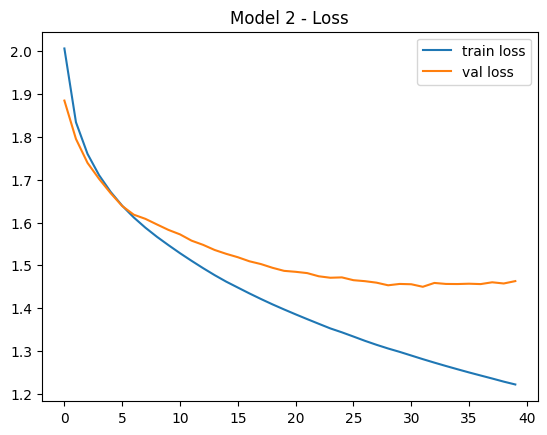

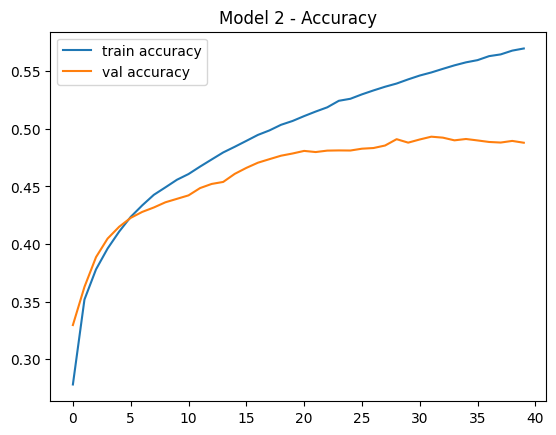

In [17]:
# Loss
plt.figure()
plt.plot(history_2.history["loss"], label="train loss")
plt.plot(history_2.history["val_loss"], label="val loss")
plt.legend()
plt.title("Model 2 - Loss")
plt.show()

# Accuracy
plt.figure()
plt.plot(history_2.history["accuracy"], label="train accuracy")
plt.plot(history_2.history["val_accuracy"], label="val accuracy")
plt.legend()
plt.title("Model 2 - Accuracy")
plt.show()

In [18]:
test_loss_2, test_accuracy_2 = model_2.evaluate(X_test, y_test)
print("Test loss 2:", test_loss_2)
print("Test accuracy 2:", test_accuracy_2)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4949 - loss: 1.4465
Test loss 2: 1.4568384885787964
Test accuracy 2: 0.48883333802223206


Increasing the number of neurons improves training performance but also increases overfitting. The training accuracy continues to rise while the validation accuracy stabilizes, creating a larger gap between the two curves.

Problem 2

In [ ]:
#He Normal model
model_he = tf.keras.Sequential()
model_he.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model_he.add(tf.keras.layers.Flatten())
model_he.add(tf.keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal"))
model_he.add(tf.keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"))
model_he.add(tf.keras.layers.Dense(10, activation="softmax"))

model_he.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

In [ ]:
#training the He normal model
history_he = model_he.fit(X_train, y_train, epochs=20,batch_size=32,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1611 - loss: 2.1943 - val_accuracy: 0.2655 - val_loss: 1.9722
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2571 - loss: 1.9788 - val_accuracy: 0.2717 - val_loss: 1.9520
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2690 - loss: 1.9477 - val_accuracy: 0.2733 - val_loss: 1.9433
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2756 - loss: 1.9277 - val_accuracy: 0.2772 - val_loss: 1.9321
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2893 - loss: 1.9059 - val_accuracy: 0.2981 - val_loss: 1.9045
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3054 - loss: 1.8840 - val_accuracy: 0.2958 - val_loss: 1.9010
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3149 - loss: 1.8682 - val_accuracy: 0.3077 - val_loss: 1.8795
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3184 - loss: 1.8606 - 

In [ ]:
#Glorot model
model_glorot = tf.keras.Sequential()
model_glorot.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model_glorot.add(tf.keras.layers.Flatten())
model_glorot.add(tf.keras.layers.Dense(20, activation="relu", kernel_initializer="glorot_uniform"))
model_glorot.add(tf.keras.layers.Dense(10, activation="relu", kernel_initializer="glorot_uniform"))
model_glorot.add(tf.keras.layers.Dense(10, activation="softmax"))

model_glorot.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

In [ ]:
#training the Glorot model
history_glorot = model_glorot.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid)
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1519 - loss: 2.2106 - val_accuracy: 0.2248 - val_loss: 2.0143
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2385 - loss: 2.0021 - val_accuracy: 0.2512 - val_loss: 1.9647
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2545 - loss: 1.9551 - val_accuracy: 0.2552 - val_loss: 1.9626
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2564 - loss: 1.9391 - val_accuracy: 0.2657 - val_loss: 1.9310
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2588 - loss: 1.9288 - val_accuracy: 0.2702 - val_loss: 1.9228
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2628 - loss: 1.9220 - val_accuracy: 0.2718 - val_loss: 1.9158
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2638 - loss: 1.9164 - val_accuracy: 0.2722 - val_loss: 1.9127
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2661 - loss: 1.9132 - 

In [ ]:
#compaire the 2 models by compairing the best validation accuracy each one delivered
print("Best val accuracy (He Normal):", max(history_he.history["val_accuracy"]))
print("Best val accuracy (Glorot Uniform):", max(history_glorot.history["val_accuracy"]))

Best val accuracy (He Normal): 0.3320833444595337
Best val accuracy (Glorot Uniform): 0.28041666746139526


On both models, the initializer was added in the hidden layers, while in the output layer the default initializer was used

In [ ]:
#create and train an SGD model using he normal initializer
model_sgd = tf.keras.Sequential()
model_sgd.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model_sgd.add(tf.keras.layers.Flatten())
model_sgd.add(tf.keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal"))
model_sgd.add(tf.keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"))
model_sgd.add(tf.keras.layers.Dense(10, activation="softmax"))

model_sgd.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.0),
    metrics=["accuracy"]
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1195 - loss: 2.2891 - val_accuracy: 0.1943 - val_loss: 2.2040
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2008 - loss: 2.1833 - val_accuracy: 0.2293 - val_loss: 2.1240
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2348 - loss: 2.1049 - val_accuracy: 0.2592 - val_loss: 2.0535
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2643 - loss: 2.0374 - val_accuracy: 0.2772 - val_loss: 1.9992
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2810 - loss: 1.9872 - val_accuracy: 0.2894 - val_loss: 1.9616
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2930 - loss: 1.9523 - val_accuracy: 0.3023 - val_loss: 1.9349
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3045 - loss: 1.9260 - val_accuracy: 0.3143 - val_loss: 1.9136
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3135 - loss: 1.9050 - 

In [ ]:
#create and train an Adam model using he normal initializer
model_adam = tf.keras.Sequential()
model_adam.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model_adam.add(tf.keras.layers.Flatten())
model_adam.add(tf.keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal"))
model_adam.add(tf.keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"))
model_adam.add(tf.keras.layers.Dense(10, activation="softmax"))

model_adam.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

history_adam = model_adam.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid)
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0987 - loss: 2.4182 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1004 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1007 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1007 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1007 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1007 - loss: 2.3041 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1007 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1007 - loss: 2.3041 - 

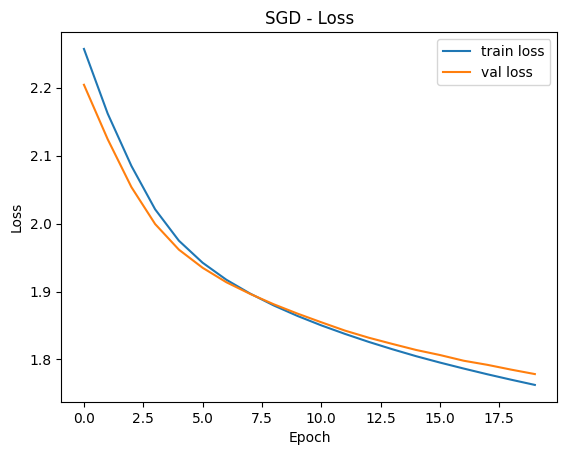

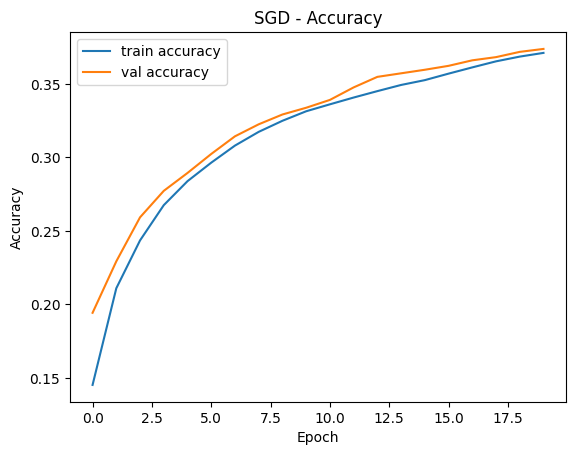

In [ ]:
#plot learning curves - SGD
plt.figure()
plt.plot(history_sgd.history["loss"], label="train loss")
plt.plot(history_sgd.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD - Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_sgd.history["accuracy"], label="train accuracy")
plt.plot(history_sgd.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SGD - Accuracy")
plt.legend()
plt.show()



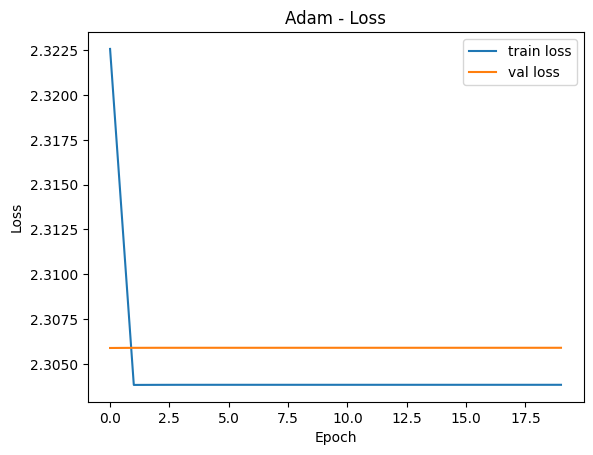

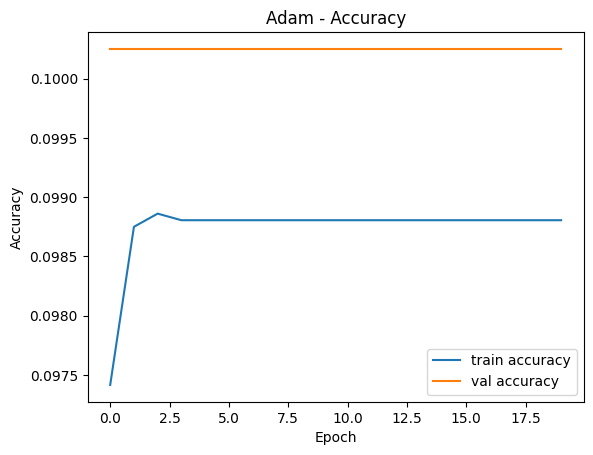

In [ ]:
#plot learing curves - Adam
plt.figure()
plt.plot(history_adam.history["loss"], label="train loss")
plt.plot(history_adam.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam - Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_adam.history["accuracy"], label="train accuracy")
plt.plot(history_adam.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Adam - Accuracy")
plt.legend()
plt.show()

SGD with a learning rate of 0.001 shows stable learning, with both training and validation loss decreasing and accuracy improving over time. Adam with a learning rate of 0.01 did not converge, with accuracy staying close to random (10%). This suggests that the learning rate for Adam was too high and the model could not train at all.

In [ ]:
#Starting from the model with He normal initializer and SGD optimizer with learning rate 0.001 and momentum 0,
#we create and train the batch normalization and dropout model.
#We will add a batch normalization after each hidden layer and one dropout after the first hidden layer

model_bn_do = tf.keras.Sequential()
model_bn_do.add(tf.keras.layers.InputLayer(input_shape=[32, 32, 3]))
model_bn_do.add(tf.keras.layers.Flatten())

model_bn_do.add(tf.keras.layers.Dense(20, activation="relu", kernel_initializer="he_normal"))
model_bn_do.add(tf.keras.layers.BatchNormalization())
model_bn_do.add(tf.keras.layers.Dropout(0.3))

model_bn_do.add(tf.keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"))
model_bn_do.add(tf.keras.layers.BatchNormalization())

model_bn_do.add(tf.keras.layers.Dense(10, activation="softmax"))

model_bn_do.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.0),
    metrics=["accuracy"]
)

history_bn_do = model_bn_do.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_valid, y_valid)
)

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1563 - loss: 2.3837 - val_accuracy: 0.2416 - val_loss: 2.1115
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2176 - loss: 2.1682 - val_accuracy: 0.2618 - val_loss: 2.0391
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2420 - loss: 2.0938 - val_accuracy: 0.2882 - val_loss: 1.9761
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2593 - loss: 2.0371 - val_accuracy: 0.2974 - val_loss: 1.9500
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2651 - loss: 2.0103 - val_accuracy: 0.3033 - val_loss: 1.9320
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2728 - loss: 1.9808 - val_accuracy: 0.3186 - val_loss: 1.8858
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2899 - loss: 1.9512 - val_accuracy: 0.3159 - val_loss: 1.8933
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2904 - loss: 1.9385 - 

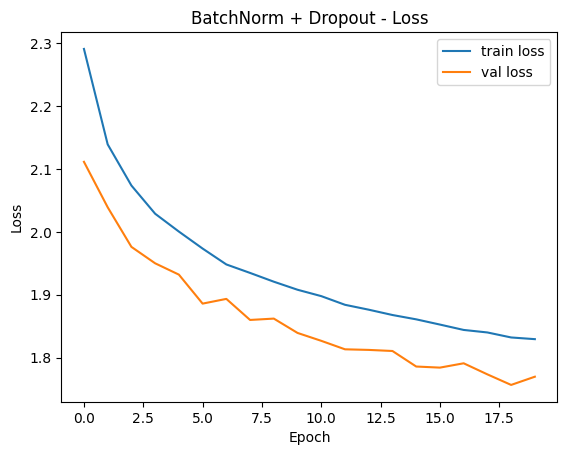

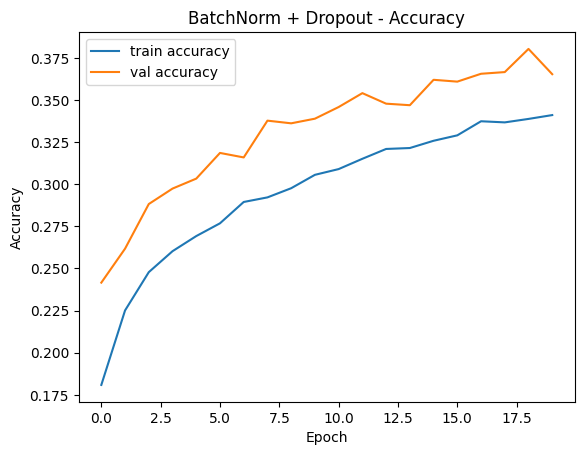

In [ ]:
#plot the loss and accuracy of the model
plt.figure()
plt.plot(history_bn_do.history["loss"], label="train loss")
plt.plot(history_bn_do.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BatchNorm + Dropout - Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_bn_do.history["accuracy"], label="train accuracy")
plt.plot(history_bn_do.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BatchNorm + Dropout - Accuracy")
plt.legend()
plt.show()

Starting from the baseline model, 2 different initializers where intoroduced. Initilazation can influence the models performance, however in this case, the differencies between he normal and glorot initializers that were used was not significant.
Regarding the optimizer choice, this excersise shows that it can have a huge impact, as the SGD with a small learning rate produced a stable training process, while the Adam optimizer failed to train the model, posibly due the high learining rate chosen.

Batch Normalization and Dropout were introduced to improve training stability and reduce overfitting. The resulting learning curves show stable training behavior and a small gap between training and validation accuracy. Models performance on the validation set is slightly better which is expected when dropout is used during training.
However, the overall validation accuracy does not significantly improve compared to the baseline model. This suggests that while these techniques help regularization, there is a clear limitation driven by the model architecture its self, which is not well suited for image classification tasks such as CIFAR-10.
Finally I was not able to complete the learining rate scheduling strategy on time for this attachment, thus I havent included any relative comments